# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
# Ваш код
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge


df = pd.read_csv("delivery_dataset.csv")


##### Шаг 1.1.
Добавил линейные признаки, чтобы побыстрее сходился градиент


In [2]:
df["average_delivery_time"] = df["Время доставки (в минутах)"] / df["Количество позиций в чеке (в шт.)"]
df["average_speed"] = df["Расстояние до клиента (в км)"] / df["Время доставки (в минутах)"]
df.head(600)

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах),average_delivery_time,average_speed
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2,79.200000,0.142677
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6,15.533333,0.156652
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3,16.300000,0.134969
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8,7.900000,0.056962
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2,4.942857,0.177746
...,...,...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9,14.450000,0.179931
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0,16.000000,0.208333
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0,9.000000,0.203704
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4,6.733333,0.175743


##### Шаг 1.2
Агрегировал данные по дате, чтобы добавить статистические признаки

In [4]:
df1 = df.groupby("Дата заказа (ГГГГ-ММ-ДД)").agg(
    average_delivery_time=("Время доставки (в минутах)", "mean"),
    average_distance=("Расстояние до клиента (в км)", "mean"),
    max_delivery_time=("Время доставки (в минутах)", "max"),
    min_delivery_time=("Время доставки (в минутах)", "min"),
    min_distance=("Расстояние до клиента (в км)", "min"),
    max_distance=("Расстояние до клиента (в км)", "max"),
    min_average_speed=("average_speed", "min"),
    max_average_speed=("average_speed", "max"),
    std_average_speed=("average_speed", "std"),
    std_average_delivery_time=("average_delivery_time", "std"),
    std_distance=("Расстояние до клиента (в км)", "std"),
    std_delivery_time=("Время доставки (в минутах)", "std"),
    average_order_per_day = ("Шифр заказа (ID)", "count"),
    position_per_day = ("Количество позиций в чеке (в шт.)", "sum")

)
df1.head()

,average_delivery_time,average_distance,max_delivery_time,min_delivery_time,min_distance,max_distance,min_average_speed,max_average_speed,std_average_speed,std_average_delivery_time,std_distance,std_delivery_time,average_order_per_day,position_per_day
Дата заказа (ГГГГ-ММ-ДД),,,,,,,,,,,,,,
2026-08-01,44.107143,8.078571,98.4,11.2,0.4,23.7,0.035714,0.240854,0.065405,15.785197,7.288471,27.681137,14,63
2026-08-02,40.287500,6.231250,91.2,12.1,0.5,15.3,0.023715,0.211409,0.057237,25.242986,5.217626,25.926560,16,58
2026-08-03,40.538462,5.923077,69.3,10.6,0.3,14.2,0.015873,0.212894,0.060307,8.365697,4.488718,19.767589,13,70
2026-08-04,43.050000,7.550000,85.0,10.4,0.4,21.1,0.028777,0.248235,0.080640,36.770296,7.792197,30.963034,10,25
2026-08-05,44.372727,7.063636,104.0,19.0,1.9,18.7,0.100000,0.231061,0.036638,14.874217,5.427757,29.727600,11,43


In [5]:
df = df.merge(
    df1,
    on="Дата заказа (ГГГГ-ММ-ДД)",
    how="left"
)

#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [6]:
date_col = "Дата заказа (ГГГГ-ММ-ДД)"
id_col = "Шифр заказа (ID)"

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sample(frac=1, random_state=42)


X = df.drop([date_col, id_col], axis=1)

start_date = df[date_col].min()
y = (df[date_col] - start_date).dt.days.astype(float)

X_train = X.iloc[:300]
X_val = X.iloc[300:400]
X_test = X.iloc[400:500]

y_train = y.iloc[:300]
y_val = y.iloc[300:400]
y_test = y.iloc[400:500]

min_train = y_train.min()
max_train = y_train.max()

y_train = (y_train - min_train) / (max_train - min_train)
y_val = (y_val - min_train) / (max_train - min_train)
y_test = (y_test - min_train) / (max_train - min_train)


##### Проверил распределение данных

<Axes: xlabel='Дата заказа (ГГГГ-ММ-ДД)', ylabel='Count'>

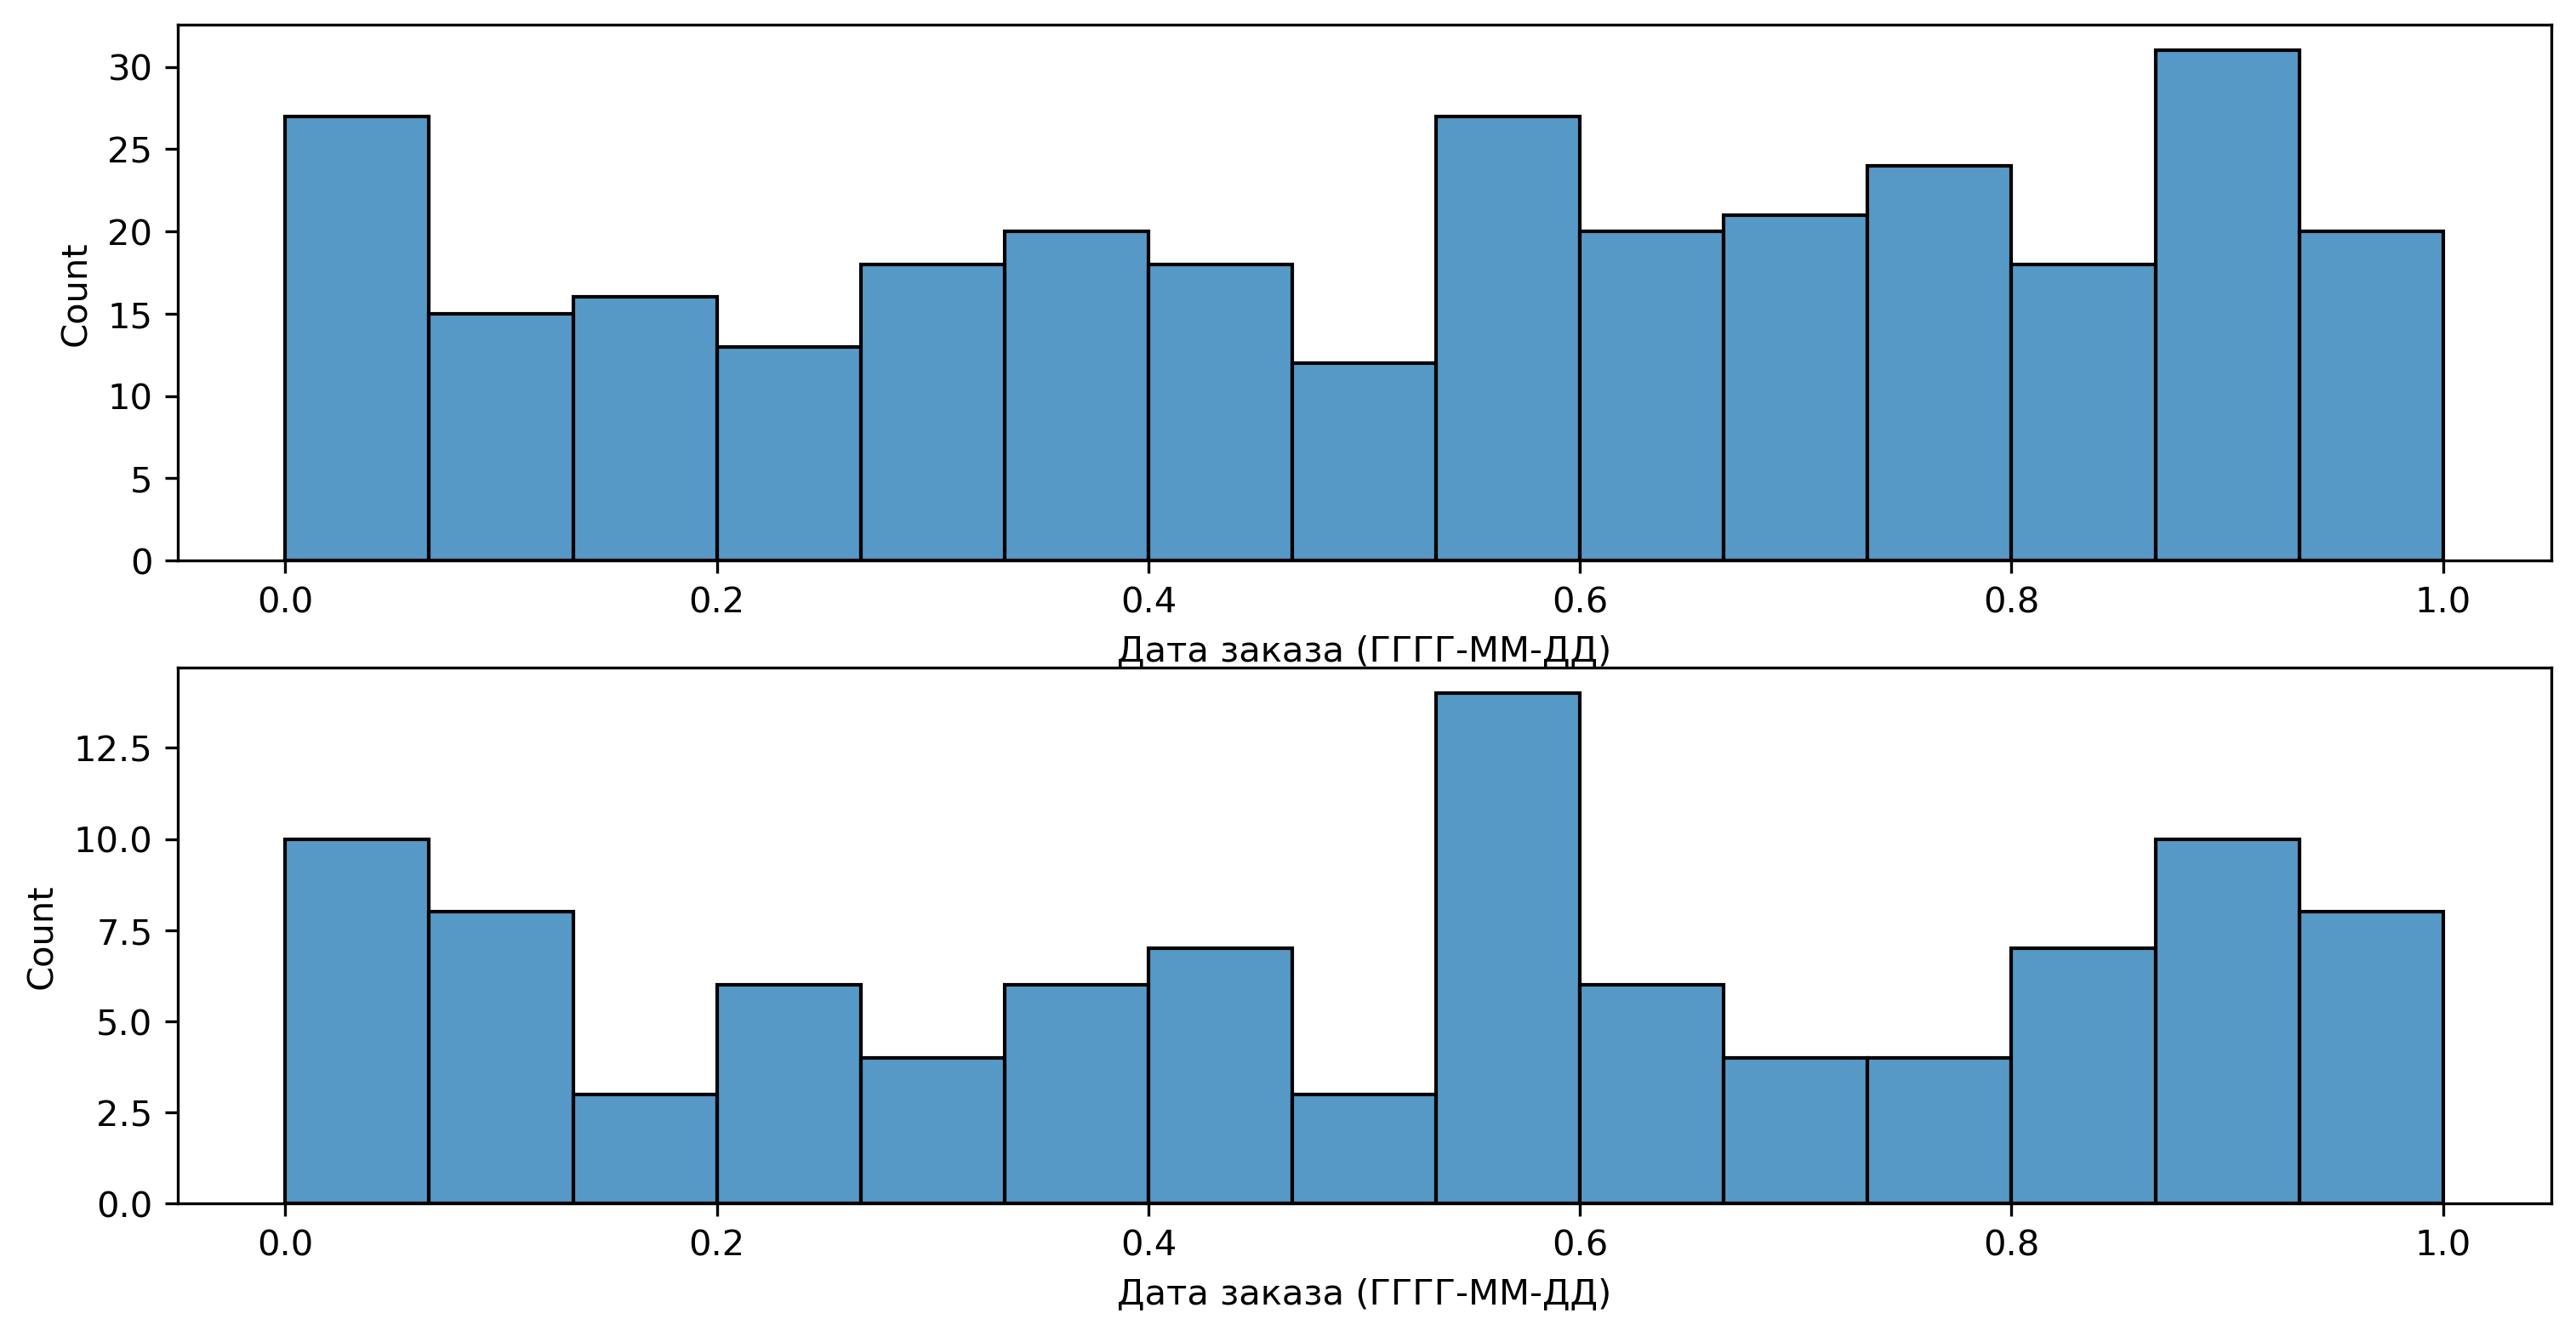

In [7]:
fig, ax = plt.subplots(2,1, figsize=(12,6), dpi=300)
sns.histplot(y_train, ax = ax[0],bins=15) 
sns.histplot(y_test, ax = ax[1],bins=15) 


#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

#### Шаг 4.2
Так как в ridge с sparse_cg нельзя посмотреть историю итераций алгоритма, поэтому использован стохастический регрессор, чтобы отслеживать прогресс обучения. В регрессоре используется регуляризация l2, чтобы это в точности был ridge.

In [18]:
# Ваш код
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

model = SGDRegressor(
    loss="squared_error",
    penalty="l2",     
    alpha=0.1,
    random_state=42
)


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

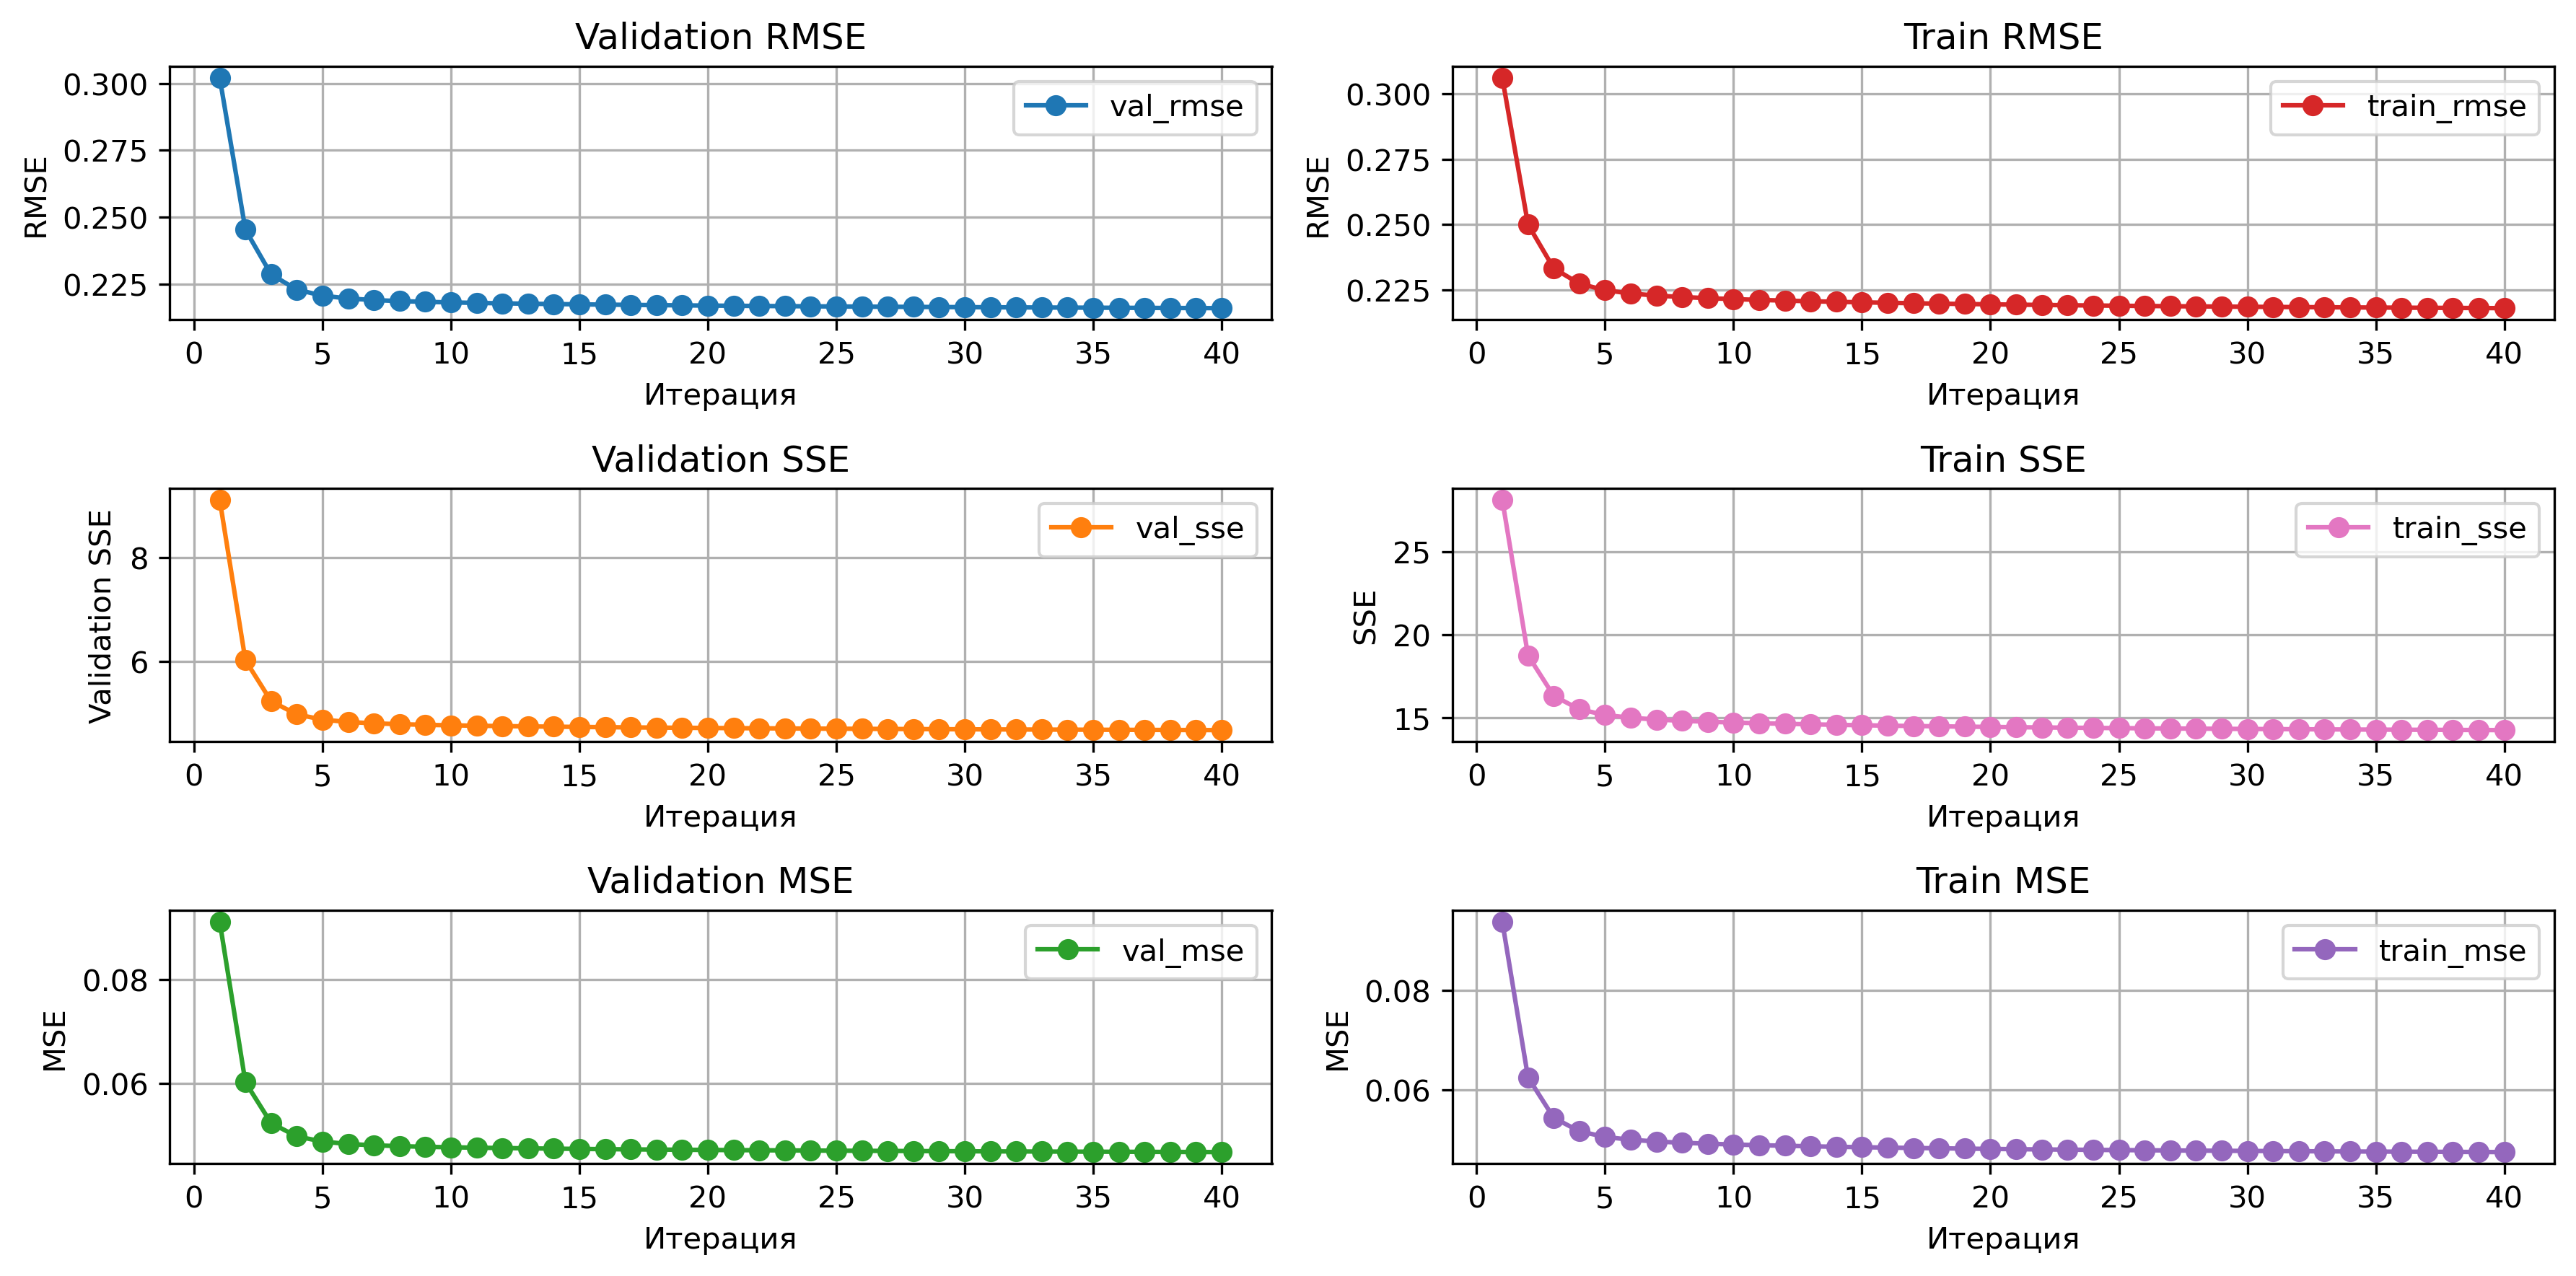

In [19]:
def SSE(y, y_pred):
    return np.sum((np.asarray(y) - np.asarray(y_pred)) ** 2)


def MSE(y, y_pred):
    return np.mean((np.asarray(y) - np.asarray(y_pred)) ** 2)


def RMSE(y, y_pred):
    return np.sqrt(MSE(y, y_pred))


n_epochs = 40

train_sse = []
train_mse = []
train_rmse = []

val_sse = []
val_mse = []
val_rmse = []

test_sse = []
test_mse =[]
test_rmse = []

for epoch in range(n_epochs):

    model.partial_fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    train_sse.append(SSE(y_train, pred_train))
    train_mse.append(MSE(y_train, pred_train))
    train_rmse.append(RMSE(y_train, pred_train))

    val_sse.append(SSE(y_val, pred_val))
    val_mse.append(MSE(y_val, pred_val))
    val_rmse.append(RMSE(y_val, pred_val))

    test_rmse.append(RMSE(y_test, pred_test))
    test_mse.append(MSE(y_test, pred_test))
    test_sse.append(SSE(y_test, pred_test))

iterations = np.arange(1, n_epochs + 1)

fig, ax = plt.subplots(3, 2, figsize=(12, 6), dpi=300)

ax[0][0].plot(iterations, val_rmse, marker="o", label="val_rmse", color="tab:blue")
ax[0][0].set_xlabel("Итерация")
ax[0][0].set_ylabel("RMSE")
ax[0][0].set_title("Validation RMSE")
ax[0][0].legend()
ax[0][0].grid()

ax[1][0].plot(iterations, val_sse, marker="o", label="val_sse", color="tab:orange")
ax[1][0].set_xlabel("Итерация")
ax[1][0].set_ylabel("Validation SSE")
ax[1][0].set_title("Validation SSE")
ax[1][0].legend()
ax[1][0].grid()

ax[2][0].plot(iterations, val_mse, marker="o", label="val_mse", color="tab:green")
ax[2][0].set_xlabel("Итерация")
ax[2][0].set_ylabel("MSE")
ax[2][0].set_title("Validation MSE")
ax[2][0].legend()
ax[2][0].grid()

ax[0][1].plot(iterations, train_rmse, marker="o", label="train_rmse", color="tab:red")
ax[0][1].set_xlabel("Итерация")
ax[0][1].set_ylabel("RMSE")
ax[0][1].set_title("Train RMSE")
ax[0][1].legend()
ax[0][1].grid()

ax[1][1].plot(iterations, train_sse, marker="o", label="train_sse",color ="tab:pink")
ax[1][1].set_xlabel("Итерация")
ax[1][1].set_ylabel("SSE")
ax[1][1].set_title("Train SSE")
ax[1][1].legend()
ax[1][1].grid()

ax[2][1].plot(iterations, train_mse, marker="o", label="train_mse", color="tab:purple")
ax[2][1].set_xlabel("Итерация")
ax[2][1].set_ylabel("MSE")
ax[2][1].set_title("Train MSE")
ax[2][1].legend()
ax[2][1].grid()

plt.tight_layout()
plt.show()


#### Шаг 6. Применение модели на тестовой выборке

In [20]:
# Ваш код
pred_test = model.predict(X_test)


#### Шаг 7. RMSE на тестовой выборке

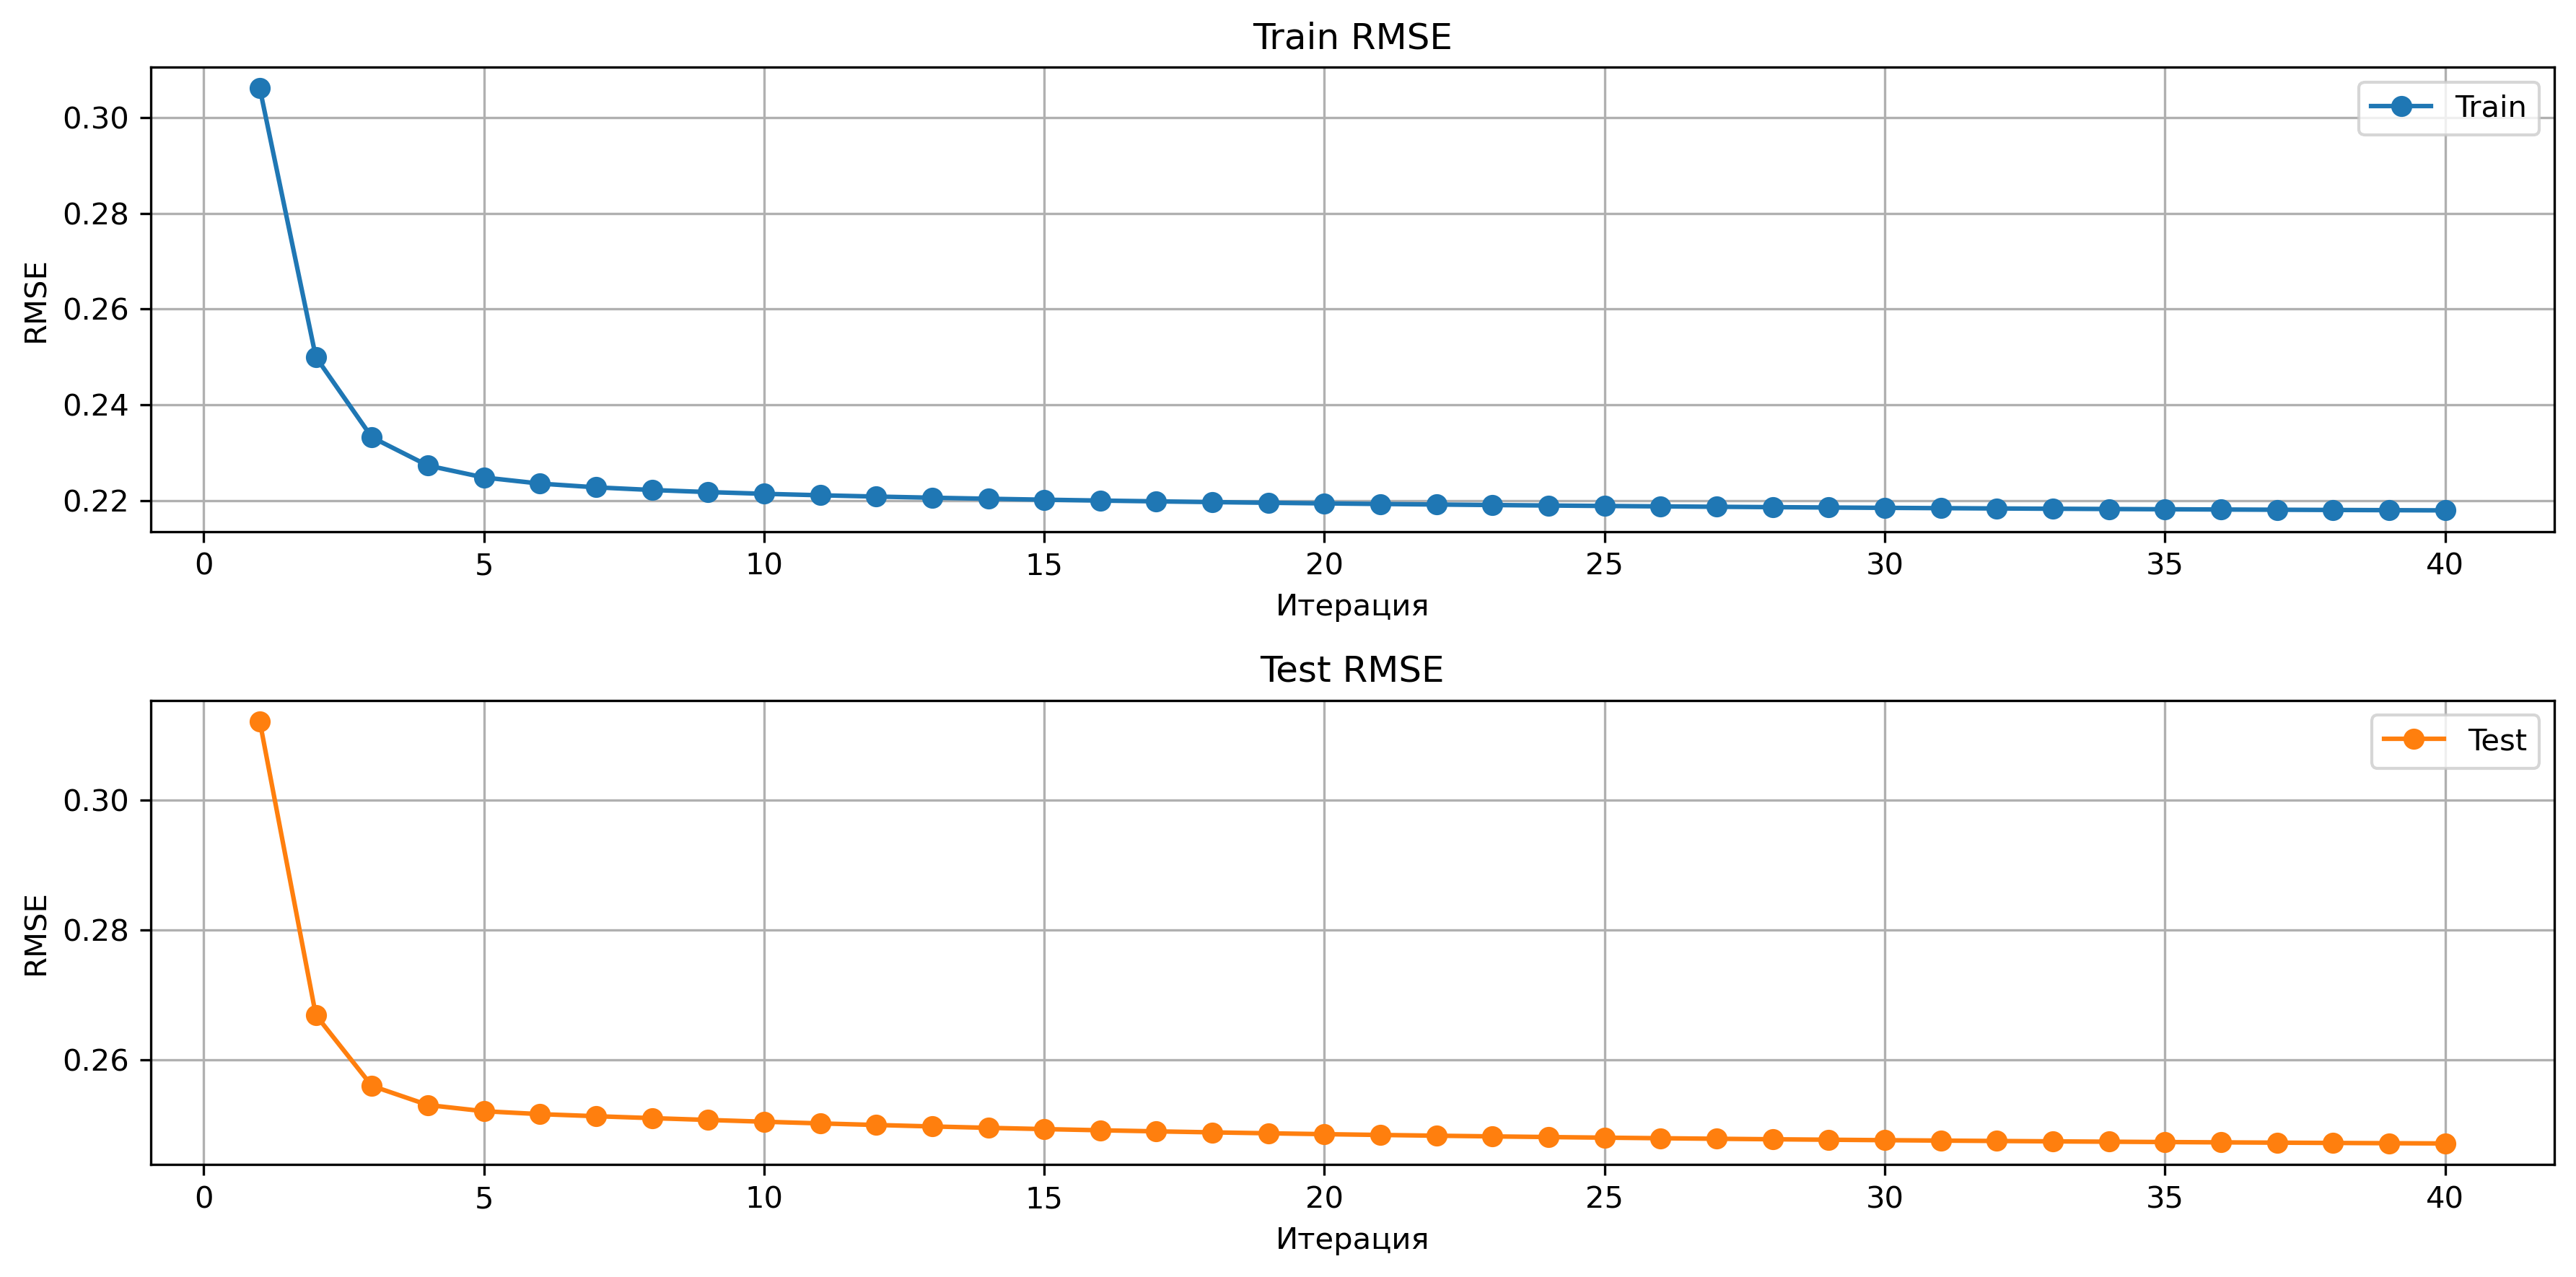

In [23]:
iterations = np.arange(1, n_epochs + 1)

fig, ax = plt.subplots(2, 1, figsize=(12, 6), dpi=300)

ax[0].plot(iterations, train_rmse, marker="o", label="Train")
ax[0].set_xlabel("Итерация")
ax[0].set_ylabel("RMSE")
ax[0].set_title("Train RMSE")
ax[0].legend()
ax[0].grid()

ax[1].plot(iterations, test_rmse, marker="o", label="Test", color="tab:orange")
ax[1].set_xlabel("Итерация")
ax[1].set_ylabel("RMSE")
ax[1].set_title("Test RMSE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()